# Chapter 265 — Generating Functions and Transforms

**Part VIII — Probability**

Generating functions are one of probability's most elegant tools: they encode an
entire distribution inside a single function, turning convolution into multiplication
and moment computation into differentiation.  This chapter builds the machinery
from first principles and shows where it surfaces in statistics and ML.


## 1. Probability Generating Functions (PGFs)

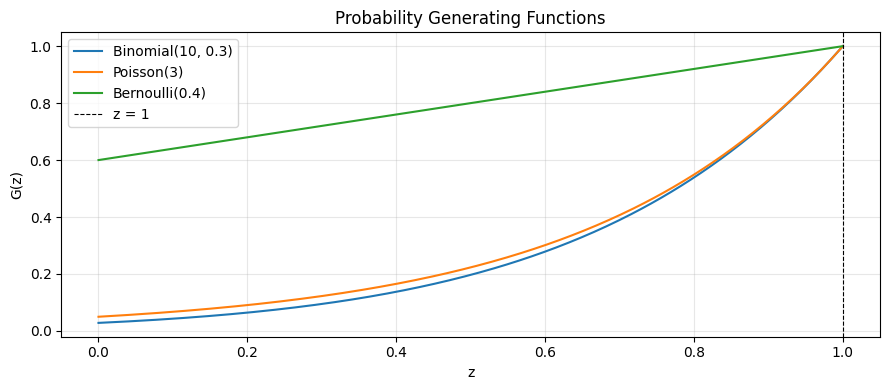

G_binom(1) = 1.0
G_pois(1)  = 1.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, binom

# For a discrete rv X with P(X=k) = p_k, the PGF is G(z) = E[z^X] = sum_k p_k z^k
# Evaluated at z=1: G(1) = 1  (normalization)
# G'(1) = E[X]          (first moment)
# G''(1) = E[X(X-1)]    (factorial moment)

def pgf_bernoulli(z, p):
    """G(z) = (1-p) + p*z"""
    return (1 - p) + p * z

def pgf_binomial(z, n, p):
    """G(z) = ((1-p) + p*z)^n  — product of n Bernoulli PGFs"""
    return ((1 - p) + p * z) ** n

def pgf_poisson(z, lam):
    """G(z) = exp(lambda*(z-1))"""
    return np.exp(lam * (z - 1))

z = np.linspace(0, 1, 300)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(z, pgf_binomial(z, 10, 0.3), label='Binomial(10, 0.3)')
ax.plot(z, pgf_poisson(z, 3.0),      label='Poisson(3)')
ax.plot(z, pgf_bernoulli(z, 0.4),    label='Bernoulli(0.4)')
ax.axvline(1, color='k', lw=0.8, ls='--', label='z = 1')
ax.set_xlabel('z'); ax.set_ylabel('G(z)')
ax.set_title('Probability Generating Functions'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('G_binom(1) =', pgf_binomial(1, 10, 0.3))   # must be 1
print('G_pois(1)  =', pgf_poisson(1, 3.0))


## 2. Extracting Moments from PGFs

In [2]:
# E[X] = G'(1),  Var[X] = G''(1) + G'(1) - [G'(1)]^2
# Use numerical differentiation so the pattern is clear

def numerical_deriv(f, z, h=1e-5):
    return (f(z + h) - f(z - h)) / (2 * h)

def numerical_deriv2(f, z, h=1e-5):
    return (f(z + h) - 2*f(z) + f(z - h)) / h**2

for name, G_fn in [
    ('Binomial(10,0.3)', lambda z: pgf_binomial(z, 10, 0.3)),
    ('Poisson(3)',       lambda z: pgf_poisson(z, 3.0)),
]:
    g1 = numerical_deriv(G_fn, 1.0 - 1e-4)   # approach from left to stay in domain
    g2 = numerical_deriv2(G_fn, 1.0 - 1e-4)
    mean_pgf = g1
    var_pgf  = g2 + g1 - g1**2
    print(f'{name}: E[X] ≈ {mean_pgf:.4f}, Var[X] ≈ {var_pgf:.4f}')

print()
print('Reference — Binomial(10,0.3): E=3.0, Var=2.1')
print('Reference — Poisson(3):       E=3.0, Var=3.0')


Binomial(10,0.3): E[X] ≈ 2.9992, Var[X] ≈ 2.1021
Poisson(3): E[X] ≈ 2.9991, Var[X] ≈ 3.0018

Reference — Binomial(10,0.3): E=3.0, Var=2.1
Reference — Poisson(3):       E=3.0, Var=3.0


## 3. Moment Generating Functions (MGFs)

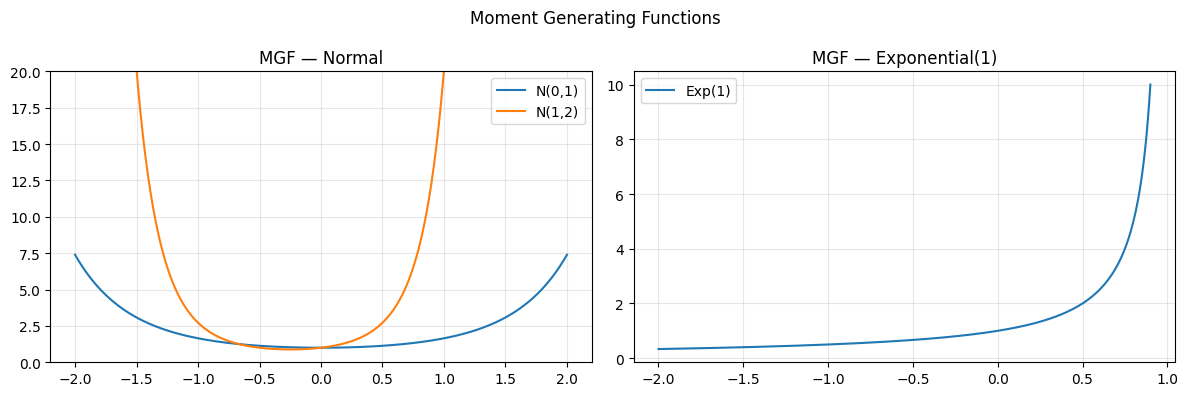

Normal(2.0,3.0): E[X] from MGF ≈ 2.0000  (true 2.0)
Normal(2.0,3.0): Var from MGF  ≈ 13.0000  (true 9.0)


In [3]:
# M_X(t) = E[e^{tX}]
# For continuous distributions this is more natural than PGF.
# E[X^k] = M^(k)(0)  — k-th derivative at t=0

def mgf_normal(t, mu, sigma):
    return np.exp(mu * t + 0.5 * sigma**2 * t**2)

def mgf_exponential(t, lam):
    # Defined only for t < lambda
    valid = t < lam
    out = np.where(valid, lam / (lam - t), np.nan)
    return out

t = np.linspace(-2, 2, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, mgf_normal(t, 0, 1), label='N(0,1)')
axes[0].plot(t, mgf_normal(t, 1, 2), label='N(1,2)')
axes[0].set_title('MGF — Normal'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 20)

t_exp = np.linspace(-2, 0.9, 400)
axes[1].plot(t_exp, mgf_exponential(t_exp, 1.0), label='Exp(1)')
axes[1].set_title('MGF — Exponential(1)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Moment Generating Functions'); plt.tight_layout(); plt.show()

# Extract moments: M'(0) = E[X], M''(0) = E[X^2]
h = 1e-5
mu, sigma = 2.0, 3.0
M = lambda t: mgf_normal(t, mu, sigma)
mean_mgf = numerical_deriv(M, 0.0)
ex2      = numerical_deriv2(M, 0.0) + numerical_deriv(M, 0.0)   # second raw moment needs care
var_mgf  = numerical_deriv2(M, 0.0)   # for MGF: Var = M''(0) - [M'(0)]^2
print(f'Normal({mu},{sigma}): E[X] from MGF ≈ {mean_mgf:.4f}  (true {mu})')
print(f'Normal({mu},{sigma}): Var from MGF  ≈ {var_mgf:.4f}  (true {sigma**2})')


## 4. MGF Convolution — Why Independence Makes Products

     t       M_X*M_Y   M_{X+Y} (exact)   match
 -1.00      0.135335          0.135335    True
 -0.50      0.286505          0.286505    True
  0.00      1.000000          1.000000    True
  0.50      5.754603          5.754603    True
  1.00     54.598150         54.598150    True


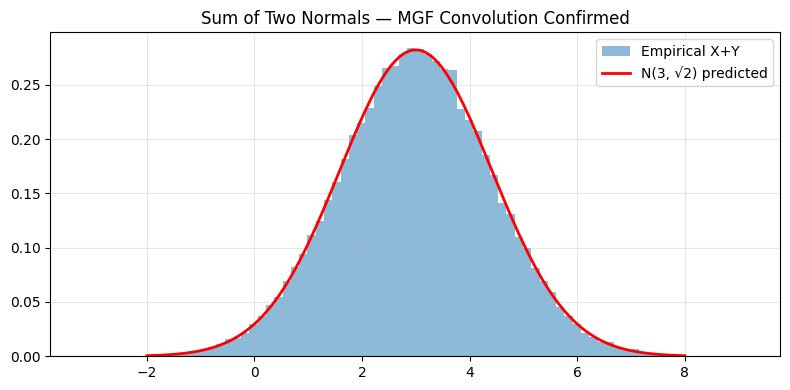

In [4]:
# If X and Y are independent, M_{X+Y}(t) = M_X(t) * M_Y(t)
# This is the MGF equivalent of the convolution theorem.
# Direct consequence: sum of independent normals is normal.

# Demonstrate numerically: X~N(1,1), Y~N(2,1), X+Y~N(3,sqrt(2))
rng = np.random.default_rng(42)
X = rng.normal(1, 1, 100_000)
Y = rng.normal(2, 1, 100_000)
Z = X + Y

t_vals = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
print(f'{'t':>6}  {'M_X*M_Y':>12}  {'M_{X+Y} (exact)':>16}  {'match':>6}')
for t in t_vals:
    product = mgf_normal(t, 1, 1) * mgf_normal(t, 2, 1)
    exact   = mgf_normal(t, 3, np.sqrt(2))
    print(f'{t:6.2f}  {product:12.6f}  {exact:16.6f}  {abs(product-exact)<1e-10!s:>6}')

# Visualize empirical Z vs N(3, sqrt(2))
xs = np.linspace(-2, 8, 300)
from scipy.stats import norm
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Z, bins=80, density=True, alpha=0.5, label='Empirical X+Y')
ax.plot(xs, norm.pdf(xs, 3, np.sqrt(2)), 'r-', lw=2, label='N(3, √2) predicted')
ax.set_title('Sum of Two Normals — MGF Convolution Confirmed')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 5. Characteristic Functions — MGF Without Convergence Worries

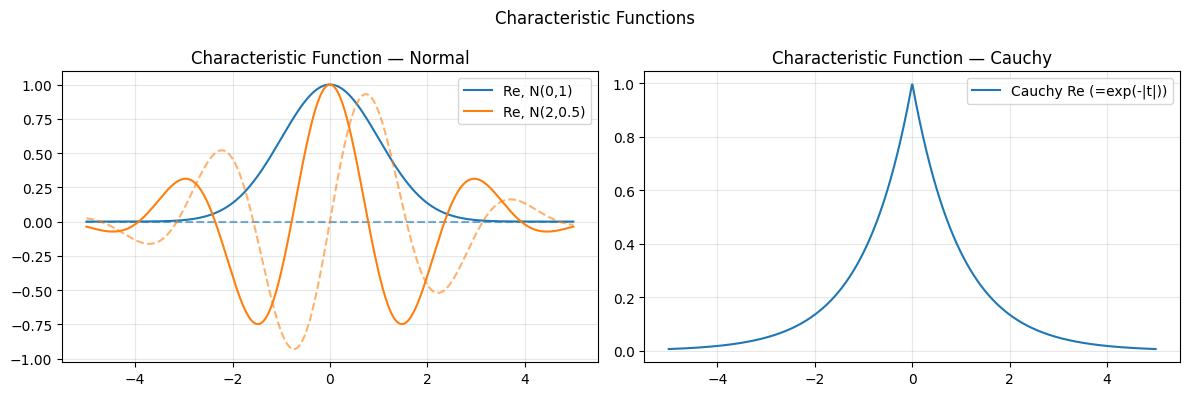

CLT characteristic function convergence:
  n=   1: phi_Sn(1.0) = 0.606531+0.000000j+0.000000j  (exact 0.606531)
  n=   5: phi_Sn(1.0) = 0.606531+0.000000j+0.000000j  (exact 0.606531)
  n=  20: phi_Sn(1.0) = 0.606531+0.000000j+0.000000j  (exact 0.606531)
  n= 100: phi_Sn(1.0) = 0.606531+0.000000j+0.000000j  (exact 0.606531)


In [5]:
# phi_X(t) = E[e^{itX}]  (i = imaginary unit)
# Always exists; |phi(t)| <= 1.
# CLT proof: phi_{S_n}(t) -> exp(-t^2/2)

# For Normal(mu, sigma): phi(t) = exp(i*mu*t - sigma^2*t^2/2)
# For Cauchy: phi(t) = exp(-|t|)  — no finite moments, MGF doesn't exist

t_arr = np.linspace(-5, 5, 1000)

def char_fn_normal(t, mu, sigma):
    return np.exp(1j * mu * t - 0.5 * sigma**2 * t**2)

def char_fn_cauchy(t):
    return np.exp(-np.abs(t))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mu, sigma, col in [(0,1,'C0'), (2,0.5,'C1')]:
    phi = char_fn_normal(t_arr, mu, sigma)
    axes[0].plot(t_arr, np.real(phi), color=col, label=f'Re, N({mu},{sigma})')
    axes[0].plot(t_arr, np.imag(phi), color=col, ls='--', alpha=0.6)
axes[0].set_title('Characteristic Function — Normal'); axes[0].legend(); axes[0].grid(alpha=0.3)

phi_c = char_fn_cauchy(t_arr)
axes[1].plot(t_arr, np.real(phi_c), label='Cauchy Re (=exp(-|t|))')
axes[1].set_title('Characteristic Function — Cauchy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Characteristic Functions'); plt.tight_layout(); plt.show()

# CLT via characteristic functions
# phi_{mean of n iid X}(t) = [phi_X(t/sqrt(n))]^n  -> exp(-t^2/2)
print('CLT characteristic function convergence:')
phi_X = lambda t: char_fn_normal(t, 0, 1)  # standardized
for n in [1, 5, 20, 100]:
    t0 = 1.0
    approx = phi_X(t0 / np.sqrt(n)) ** n
    exact  = np.exp(-t0**2 / 2)
    print(f'  n={n:4d}: phi_Sn({t0}) = {approx:.6f}+{approx.imag:.6f}j  (exact {exact:.6f})')


## 6. Summary

| Transform | Domain | Key property |
|-----------|--------|-------------|
| PGF G(z) | Discrete | G^(k)(0)/k! = P(X=k) |
| MGF M(t) | Continuous/discrete | M^(k)(0) = E[X^k] |
| Characteristic φ(t) | Any | Always exists; |φ|≤1 |

- **Convolution → multiplication**: independence turns the hard operation into the easy one.
- **Moment extraction**: differentiate at 0.
- **CLT**: characteristic functions make the proof rigorous *(ch254 — Central Limit Theorem)*.

*(introduced in ch249 — Expected Value, ch250 — Variance)*


## 7. Forward References

- **ch271 — Data and Measurement**: sampling distributions derived from MGF arguments.
- **ch280 — Hypothesis Testing**: test statistics whose distributions follow from characteristic functions.
- **ch295 — Information Theory**: entropy as the log of a normalizing constant in exponential families — same transform machinery.
